# Feature Selection Method Comparison

Each section covers one model. Within each section the same train/test split is used to rank features by four methods — SHAP, Gain, LIME, and Information Gain — then evaluates top-k (k = 1…10) features and plots a per-metric comparison.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import copy
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from lime.lime_tabular import LimeTabularExplainer

import lightgbm as lgb
import xgboost as xgb
import importlib
import bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison


/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
for mod in (bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison):
    importlib.reload(mod)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
print("Modules reloaded.")

Modules reloaded.


### Data

In [3]:
seed = 123
os.makedirs(f"figures/fraud_{seed}", exist_ok=True)

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)
df = pd.read_csv(f"{path}/creditcard.csv")

Path to dataset files: /home/francesx/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [5]:
X = df.drop(columns=['Class'])
y = df['Class']

# Amount and Time are raw features (unlike V1-V28 which are already PCA-transformed).
# Log-scaling Amount reduces the long right tail; Time is cyclic so we keep as-is but scale.
X = X.copy()
X['Amount'] = np.log1p(X['Amount'])
X['Time'] = (X['Time'] - X['Time'].mean()) / X['Time'].std()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (227845, 30), Test: (56962, 30)


In [6]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
# Step 1: undersample class 0 so minority = 10% of majority
under = RandomUnderSampler(sampling_strategy=0.1, random_state=seed)
X_res, y_res = under.fit_resample(X_train, y_train)

# Step 2: SMOTE class 1 up to 1:1
over = SMOTE(sampling_strategy=1.0, random_state=seed)
X_train_smote, y_train_smote = over.fit_resample(X_res, y_res)
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote = pd.Series(y_train_smote, name=y_train.name)
print(f"After undersample+SMOTE — Train: {X_train_smote.shape}")
print(f"Class distribution: {y_train_smote.value_counts().to_dict()}")

After undersample+SMOTE — Train: (7880, 30)
Class distribution: {0: 3940, 1: 3940}


### Model Wrappers

In [7]:
lgb_wrapper = create_model_wrapper(
    'lightgbm',
    params={
        'objective': 'binary', 'metric': 'average_precision',
        'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 31,
        'min_data_in_leaf': 20, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 5,
        'verbose': -1, 'seed': seed, 'num_threads': 1,
    },
    num_boost_round=300,
)

xgb_wrapper = create_model_wrapper(
    'xgboost',
    params={
        'objective': 'binary:logistic', 'eval_metric': 'logloss',
        'eta': 0.05, 'max_depth': 6, 'subsample': 0.8,
        'colsample_bytree': 0.8, 'seed': seed,
    },
    num_boost_round=300,
)

rf_wrapper = create_model_wrapper(
    'sklearn', model_class=RandomForestClassifier,
    model_params={'n_estimators': 200, 'random_state': seed, 'max_depth': 10, 'min_samples_leaf': 5},
    use_tree_explainer=True,
)

cb_wrapper = create_model_wrapper(
    'catboost',
    params={
        'random_seed': seed, 'learning_rate': 0.05, 'depth': 6,
        'eval_metric': 'Logloss', 'iterations': 300,
    },
)

gb_wrapper = create_model_wrapper(
    'sklearn', model_class=GradientBoostingClassifier,
    model_params={'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05,
                  'subsample': 0.8, 'random_state': seed},
    use_tree_explainer=True,
)

lr_wrapper = create_model_wrapper(
    'sklearn', model_class=LogisticRegression,
    model_params={'random_state': seed, 'max_iter': 1000, 'C': 1.0, 'solver': 'saga'},
    use_linear_explainer=True, use_tree_explainer=False,
)

MODELS = {
    'LightGBM':          lgb_wrapper,
    'XGBoost':           xgb_wrapper,
    'RandomForest':      rf_wrapper,
    'CatBoost':          cb_wrapper,
    'GradientBoosting':  gb_wrapper,
    'LogisticRegression': lr_wrapper,
}


### Helper Functions

In [8]:
def _clone_wrapper(wrapper, input_dim=None):
    if isinstance(wrapper, XGBoostWrapper):
        return XGBoostWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, LightGBMWrapper):
        return LightGBMWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, SklearnWrapper):
        return SklearnWrapper(
            model_class=wrapper.model_class,
            model_params=wrapper.model_params.copy(),
            use_tree_explainer=wrapper.use_tree_explainer,
            use_linear_explainer=wrapper.use_linear_explainer,
        )
    if isinstance(wrapper, CatBoostWrapper):
        return CatBoostWrapper(params=wrapper.params.copy(), num_boost_round=getattr(wrapper, 'num_boost_round', 100))
    return copy.deepcopy(wrapper)


def _predict_proba(wrapper, X):
    if isinstance(wrapper, XGBoostWrapper):
        p = wrapper.model.predict(xgb.DMatrix(X, enable_categorical=True))
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, LightGBMWrapper):
        p = wrapper.model.predict(X)
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, (CatBoostWrapper, SklearnWrapper)):
        return wrapper.model.predict_proba(X)
    raise TypeError(f'Unknown wrapper: {type(wrapper)}')


def get_shap_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
        task = 'binary'
        sv = w.compute_shap(X_tr, task=task)
    importance = np.abs(sv).sum(axis=tuple(range(sv.ndim - 1)))
    return (
        pd.DataFrame({'feature': X_tr.columns, 'importance': importance})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_gain_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    if isinstance(w, LightGBMWrapper):
        imp = w.model.feature_importance(importance_type='gain').astype(float)
    elif isinstance(w, XGBoostWrapper):
        scores = w.model.get_score(importance_type='gain')
        imp = np.array([scores.get(f, 0.0) for f in X_tr.columns], dtype=float)
    elif isinstance(w, CatBoostWrapper):
        imp = np.array(w.model.get_feature_importance(), dtype=float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'feature_importances_'):
        imp = w.model.feature_importances_.astype(float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'coef_'):
        imp = np.abs(w.model.coef_).ravel().astype(float)
    else:
        return None
    return (
        pd.DataFrame({'feature': X_tr.columns.tolist(), 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_lime_ranking(wrapper, X_tr, y_tr, n_samples=10, num_features=50):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    X_arr = X_tr.values.astype(float)
    feat_names = X_tr.columns.tolist()
    def _pred(arr, _w=w):
        return _predict_proba(_w, pd.DataFrame(arr, columns=feat_names))
    explainer = LimeTabularExplainer(
        X_arr, feature_names=feat_names,
        class_names=['0', '1'], mode='classification', random_state=42,
    )
    idx = np.random.RandomState(42).choice(len(X_arr), min(n_samples, len(X_arr)), replace=False)
    imp = np.zeros(len(feat_names))
    for i in idx:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            exp = explainer.explain_instance(X_arr[i], _pred, num_features=num_features)
        for fi, w_val in exp.local_exp[1]:
            imp[fi] += abs(w_val)
    imp /= len(idx)
    return (
        pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


# def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
#     results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
#     for k in k_values:
#         feats = ranking_df['feature'].head(k).tolist()
#         try:
#             w = _clone_wrapper(wrapper, input_dim=k)
#             with warnings.catch_warnings():
#                 warnings.simplefilter('ignore')
#                 w.fit(X_tr[feats], y_tr)
#                 proba = _predict_proba(w, X_te[feats])
#             p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
#             y_pred = (p_pos >= 0.5).astype(int)
#             results['accuracy'].append(accuracy_score(y_te, y_pred))
#             results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
#             results['ap'].append(average_precision_score(y_te, p_pos))
#             results['auc'].append(roc_auc_score(y_te, p_pos))
#         except Exception as e:
#             for m in results:
#                 results[m].append(float('nan'))
#     return results

def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
    results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
    for k in k_values:
        selected = ranking_df['feature'].head(k).tolist()
        selected_set = set(selected)
        feats = [c for c in X_tr.columns if c in selected_set]  # fixed order

        try:
            w = _clone_wrapper(wrapper, input_dim=len(feats))
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                w.fit(X_tr[feats], y_tr)
                proba = _predict_proba(w, X_te[feats])
            p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
            y_pred = (p_pos >= 0.5).astype(int)
            results['accuracy'].append(accuracy_score(y_te, y_pred))
            results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
            results['ap'].append(average_precision_score(y_te, p_pos))
            results['auc'].append(roc_auc_score(y_te, p_pos))
        except Exception:
            for m in results:
                results[m].append(float('nan'))
    return results


def plot_comparison(model_name, all_results, k_values=list(range(1, 11))):
    metric_keys   = ['accuracy', 'f1',       'ap',                'auc'    ]
    metric_titles = ['Accuracy', 'F1 Score', 'Average Precision', 'AUC-ROC']
    method_styles = {
        'SHAP': dict(color='steelblue',  linestyle='-',  marker='o'),
        'Gain': dict(color='darkorange', linestyle='--', marker='s'),
        'LIME': dict(color='green',      linestyle='-.', marker='^'),
        'IG':   dict(color='crimson',    linestyle=':',  marker='D'),
        'Robust': dict(color='purple',   linestyle='-',  marker='X'),
    }
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    for ax, key, title in zip(axes.flatten(), metric_keys, metric_titles):
        for method, res in all_results.items():
            if res is None:
                continue
            ax.plot(k_values, res[key], linewidth=1.8, markersize=5,
                    label=method, **method_styles.get(method, {}))
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('k (number of features)')
        ax.set_ylabel(title)
        ax.set_xticks(k_values)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f'{model_name} — Feature Selection Comparison',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"figures/fraud_{seed}/fraud_{model_name}_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()


### Information Gain Ranking (computed once, model-agnostic)

In [9]:
print('Computing Information Gain scores...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ig_scores = mutual_info_classif(X_train_smote, y_train_smote, random_state=42)

ig_ranking = (
    pd.DataFrame({'feature': X_train_smote.columns, 'importance': ig_scores})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
print('Top-10 IG features:')
ig_ranking.head(10)


Computing Information Gain scores...
Top-10 IG features:


,feature,importance
0,V14,0.495433
1,V10,0.439400
2,V12,0.438167
3,V17,0.436308
4,V11,0.405028
5,V4,0.400073
6,V3,0.359254
7,V16,0.353043
8,V7,0.309200
9,V2,0.282462


---
## LightGBM

### LightGBM — SHAP

In [10]:
print('Computing SHAP ranking for LightGBM...')
lightgbm_shap = get_shap_ranking(MODELS['LightGBM'], X_train_smote, y_train_smote)
print('Top-10:')
lightgbm_shap.head(10)


Computing SHAP ranking for LightGBM...
Top-10:


,feature,importance
0,V14,26737.003941
1,V4,12142.501725
2,V12,9960.093558
3,V10,8844.267821
4,V17,6380.019687
5,V3,3715.240517
6,V18,2651.739167
7,V8,2575.890417
8,Amount,2530.324044
9,V11,2415.901202


### LightGBM — Gain

In [11]:
print('Computing Gain ranking for LightGBM...')
lightgbm_gain = get_gain_ranking(MODELS['LightGBM'], X_train_smote, y_train_smote)
if lightgbm_gain is not None:
    print('Top-10:')
    display(lightgbm_gain.head(10))
else:
    print('Gain not supported for LightGBM')


Computing Gain ranking for LightGBM...
Top-10:


,feature,importance
0,V14,40274.965161
1,V10,19788.986561
2,V4,6156.823784
3,V12,5742.317731
4,V17,1884.294416
5,V8,1637.974728
6,V3,1312.127147
7,V18,1173.245039
8,V11,1129.248612
9,Amount,1051.536586


### LightGBM — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [12]:
print('Computing LIME ranking for LightGBM...')
lightgbm_lime = get_lime_ranking(
    MODELS['LightGBM'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
lightgbm_lime.head(10)

Computing LIME ranking for LightGBM...
Top-10:


,feature,importance
0,V14,0.308535
1,V4,0.169764
2,V12,0.141503
3,V10,0.080571
4,V17,0.063064
5,V3,0.061078
6,V8,0.030286
7,Amount,0.028664
8,V11,0.028056
9,V9,0.027898


### LightGBM — Robust

In [ ]:
lgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,  # Use preprocessed data with one-hot encoded categoricals
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):  88%|████████▊ | 442/500 [01:46<00:14,  4.14it/s]

In [ ]:
lgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [ ]:
tmp = lgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

lightgbm_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
lightgbm_robust.head(10)


,feature,importance
Rank,,
1,V14,28254.674023
2,V4,15105.403985
3,V12,11134.254682
4,V10,8696.998821
5,V1,4924.015827
6,V11,4598.124490
7,V3,4470.038081
8,V17,4196.204862
9,V8,3291.582711


### LightGBM — Evaluation & Comparison

Evaluating LightGBM — SHAP...
Evaluating LightGBM — Gain...
Evaluating LightGBM — LIME...
Evaluating LightGBM — IG...
Evaluating LightGBM — Robust Bootstrap...


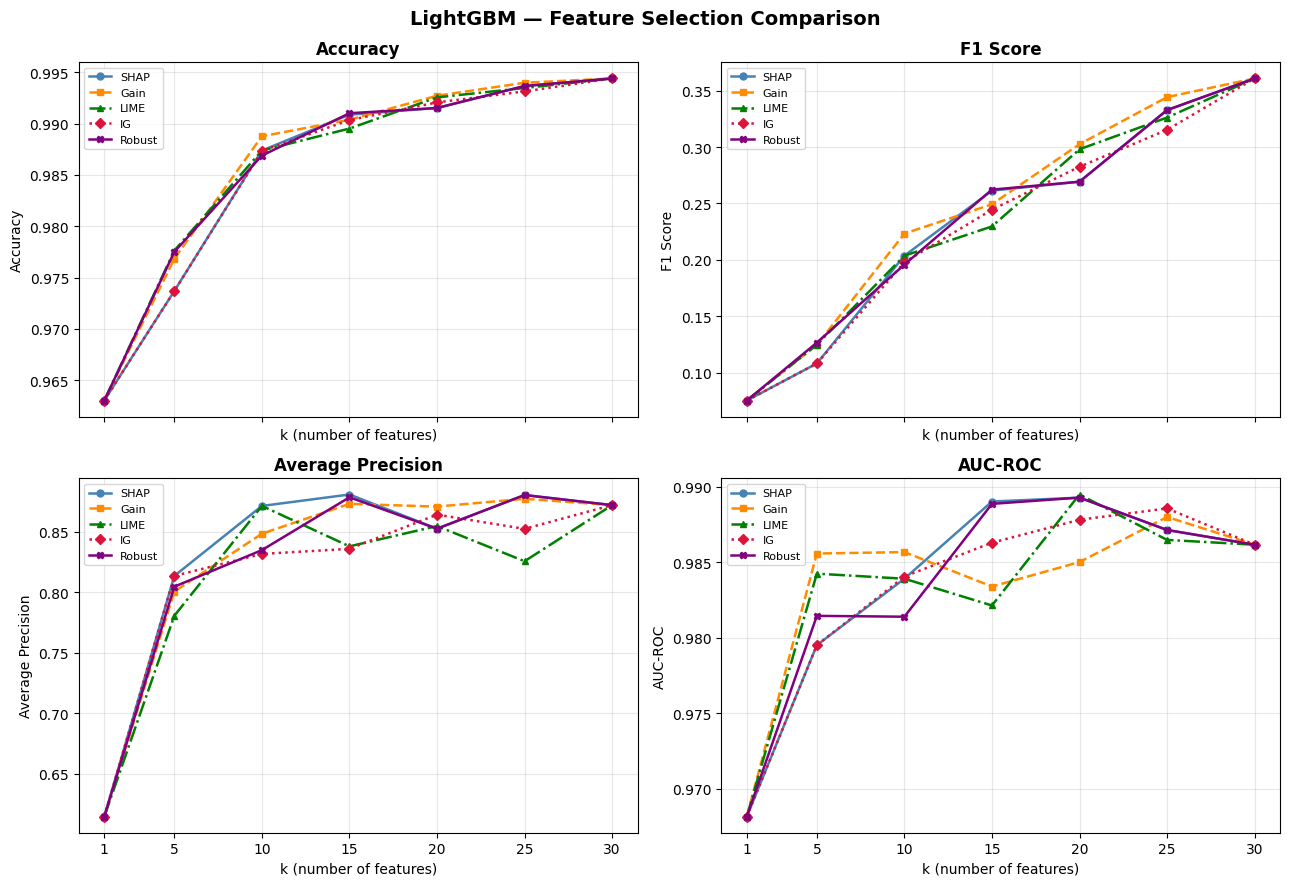

In [ ]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating LightGBM — SHAP...')
lightgbm_res_shap = evaluate_topk(MODELS['LightGBM'], lightgbm_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LightGBM — Gain...')
lightgbm_res_gain = evaluate_topk(MODELS['LightGBM'], lightgbm_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if lightgbm_gain is not None else None

print('Evaluating LightGBM — LIME...')
lightgbm_res_lime = evaluate_topk(MODELS['LightGBM'], lightgbm_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LightGBM — IG...')
lightgbm_res_ig = evaluate_topk(MODELS['LightGBM'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LightGBM — Robust Bootstrap...')
lightgbm_res_robust = evaluate_topk(MODELS['LightGBM'], lightgbm_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'LightGBM',
    {'SHAP': lightgbm_res_shap, 'Gain': lightgbm_res_gain,
     'LIME': lightgbm_res_lime, 'IG':   lightgbm_res_ig, 'Robust': lightgbm_res_robust},
    k_values,
)


---
## XGBoost

### XGBoost — SHAP

In [ ]:
print('Computing SHAP ranking for XGBoost...')
xgboost_shap = get_shap_ranking(MODELS['XGBoost'], X_train_smote, y_train_smote)
print('Top-10:')
xgboost_shap.head(10)


Computing SHAP ranking for XGBoost...
Top-10:


,feature,importance
0,V14,21972.951172
1,V4,10264.826172
2,V12,7264.570312
3,V17,5425.968750
4,V10,4545.255371
5,V8,4213.583008
6,Time,2752.955566
7,V11,2498.595947
8,Amount,2390.240234
9,V18,2319.812012


### XGBoost — Gain

In [ ]:
print('Computing Gain ranking for XGBoost...')
xgboost_gain = get_gain_ranking(MODELS['XGBoost'], X_train_smote, y_train_smote)
if xgboost_gain is not None:
    print('Top-10:')
    display(xgboost_gain.head(10))
else:
    print('Gain not supported for XGBoost')


Computing Gain ranking for XGBoost...
Top-10:


,feature,importance
0,V14,128.718719
1,V10,43.055950
2,V4,14.601932
3,V12,13.051332
4,V11,8.555364
5,V8,6.620853
6,V17,6.133670
7,V3,6.098253
8,Amount,5.180302
9,V7,4.835132


### XGBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [ ]:
print('Computing LIME ranking for XGBoost...')
xgboost_lime = get_lime_ranking(
    MODELS['XGBoost'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
xgboost_lime.head(10)


Computing LIME ranking for XGBoost...
Top-10:


,feature,importance
0,V14,0.321010
1,V4,0.213467
2,V12,0.164441
3,V10,0.093217
4,V17,0.076615
5,V3,0.059809
6,V8,0.045607
7,Amount,0.041058
8,V11,0.033447
9,V15,0.028097


### XGBoost — Robust

In [ ]:
xgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=xgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   0%|          | 0/500 [00:00<?, ?it/s]

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [01:13<00:00,  6.77it/s]


In [ ]:
xgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [ ]:
tmp = xgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

xgboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
xgboost_robust.head(10)


,feature,importance
Rank,,
1,V14,20584.093792
2,V4,10630.608401
3,V12,8585.738876
4,V10,7217.928783
5,V8,4033.795746
6,V17,3846.233800
7,V11,3200.046670
8,V1,2730.486045
9,Time,2704.631937


### XGBoost — Evaluation & Comparison

Evaluating XGBoost — SHAP...
Evaluating XGBoost — Gain...
Evaluating XGBoost — LIME...
Evaluating XGBoost — IG...
Evaluating XGBoost — Robust Bootstrap...


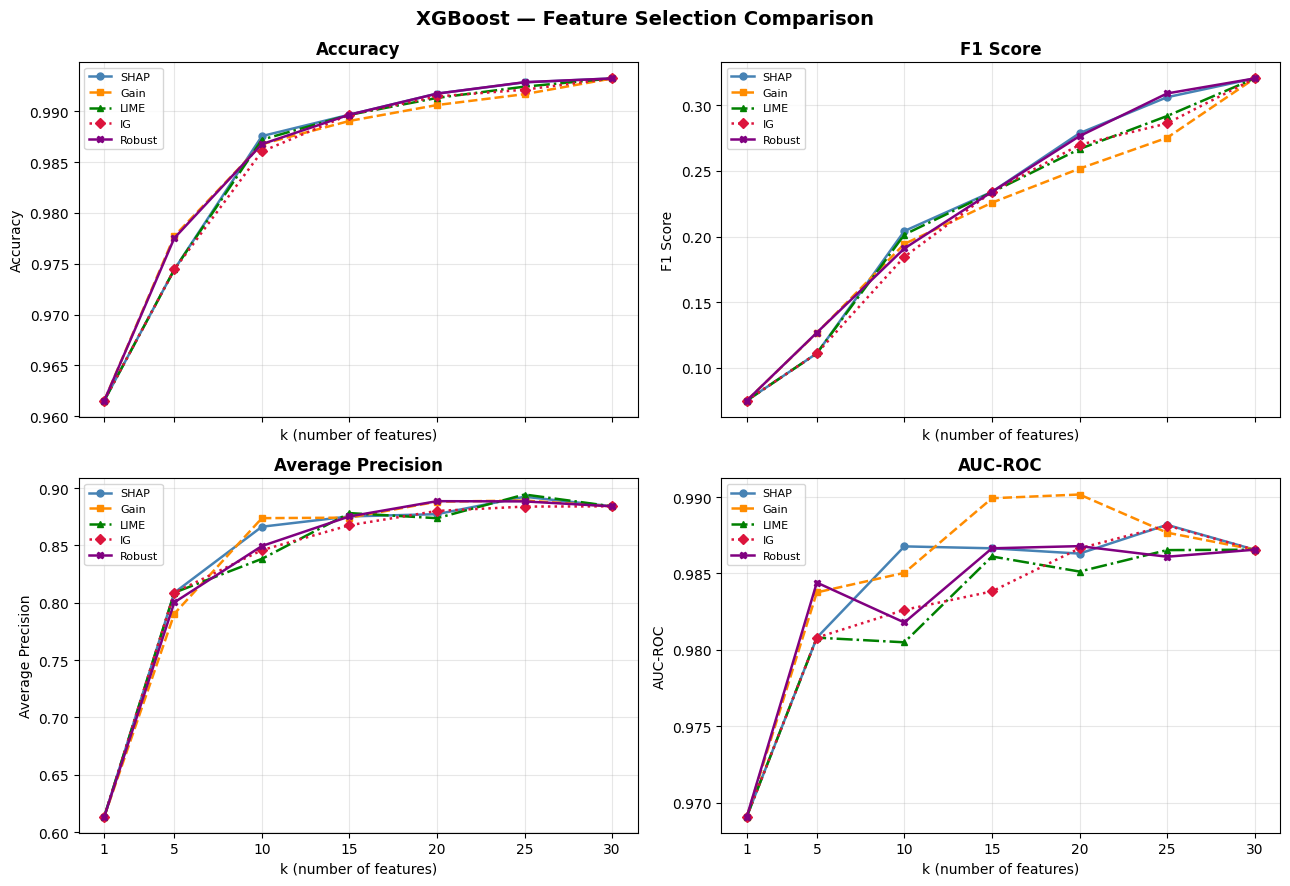

In [ ]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating XGBoost — SHAP...')
xgboost_res_shap = evaluate_topk(MODELS['XGBoost'], xgboost_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating XGBoost — Gain...')
xgboost_res_gain = evaluate_topk(MODELS['XGBoost'], xgboost_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if xgboost_gain is not None else None

print('Evaluating XGBoost — LIME...')
xgboost_res_lime = evaluate_topk(MODELS['XGBoost'], xgboost_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating XGBoost — IG...')
xgboost_res_ig = evaluate_topk(MODELS['XGBoost'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating XGBoost — Robust Bootstrap...')
xgboost_res_robust = evaluate_topk(MODELS['XGBoost'], xgboost_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'XGBoost',
    {'SHAP': xgboost_res_shap, 'Gain': xgboost_res_gain,
     'LIME': xgboost_res_lime, 'IG':   xgboost_res_ig, 'Robust': xgboost_res_robust},
    k_values,
)

---
## RandomForest

### RandomForest — SHAP

In [ ]:
print('Computing SHAP ranking for RandomForest...')
randomforest_shap = get_shap_ranking(MODELS['RandomForest'], X_train_smote, y_train_smote)
print('Top-10:')
randomforest_shap.head(10)


Computing SHAP ranking for RandomForest...
Top-10:


,feature,importance
0,V14,867.381419
1,V4,618.845237
2,V12,569.383052
3,V10,482.246137
4,V11,365.582596
5,V17,264.517447
6,V3,162.401240
7,V16,157.475404
8,V7,133.890895
9,V8,75.904902


### RandomForest — Gain

In [ ]:
print('Computing Gain ranking for RandomForest...')
randomforest_gain = get_gain_ranking(MODELS['RandomForest'], X_train_smote, y_train_smote)
if randomforest_gain is not None:
    print('Top-10:')
    display(randomforest_gain.head(10))
else:
    print('Gain not supported for RandomForest')


Computing Gain ranking for RandomForest...
Top-10:


,feature,importance
0,V14,0.169639
1,V12,0.135930
2,V4,0.130081
3,V10,0.122737
4,V11,0.097031
5,V17,0.070411
6,V16,0.045549
7,V7,0.035923
8,V3,0.032893
9,V2,0.017627


### RandomForest — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [ ]:
print('Computing LIME ranking for RandomForest...')
randomforest_lime = get_lime_ranking(
    MODELS['RandomForest'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
randomforest_lime.head(10)

Computing LIME ranking for RandomForest...
Top-10:


,feature,importance
0,V14,0.148983
1,V12,0.110622
2,V4,0.109663
3,V10,0.075028
4,V3,0.047170
5,V11,0.045674
6,V17,0.042626
7,V16,0.024577
8,V7,0.019708
9,V8,0.014099


### RandomForest — Robust

In [ ]:
rf_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1,
    zero_tol=0,
    model_wrapper=rf_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [30:20<00:00,  3.64s/it]


In [ ]:
rf_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=rf_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [ ]:
tmp = rf_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

rf_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
rf_robust.head(10)


,feature,importance
Rank,,
1,V14,817.132196
2,V4,608.049625
3,V10,518.439690
4,V12,495.565882
5,V11,368.436196
6,V17,316.918202
7,V3,226.681829
8,V16,190.520011
9,V7,146.099541


### RandomForest — Evaluation & Comparison

Evaluating RandomForest — SHAP...
Evaluating RandomForest — Gain...
Evaluating RandomForest — LIME...
Evaluating RandomForest — IG...
Evaluating RandomForest — Robust Bootstrap...


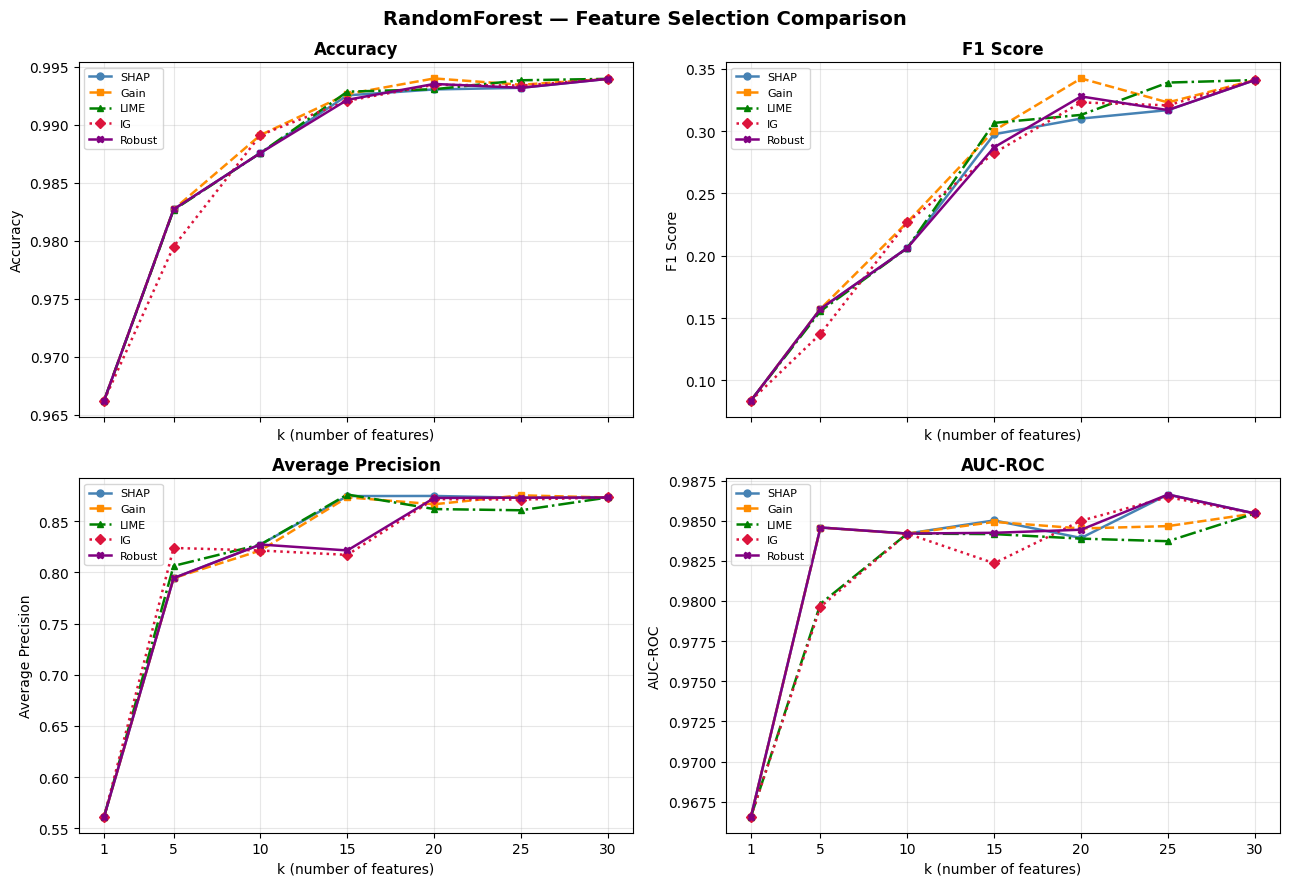

In [ ]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating RandomForest — SHAP...')
randomforest_res_shap = evaluate_topk(MODELS['RandomForest'], randomforest_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating RandomForest — Gain...')
randomforest_res_gain = evaluate_topk(MODELS['RandomForest'], randomforest_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if randomforest_gain is not None else None

print('Evaluating RandomForest — LIME...')
randomforest_res_lime = evaluate_topk(MODELS['RandomForest'], randomforest_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating RandomForest — IG...')
randomforest_res_ig = evaluate_topk(MODELS['RandomForest'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating RandomForest — Robust Bootstrap...')
randomforest_res_robust = evaluate_topk(MODELS['RandomForest'], rf_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'RandomForest',
    {'SHAP': randomforest_res_shap, 'Gain': randomforest_res_gain,
     'LIME': randomforest_res_lime, 'IG':   randomforest_res_ig, 'Robust': randomforest_res_robust},
    k_values,
)


---
## CatBoost

### CatBoost — SHAP

In [ ]:
print('Computing SHAP ranking for CatBoost...')
catboost_shap = get_shap_ranking(MODELS['CatBoost'], X_train_smote, y_train_smote)
print('Top-10:')
catboost_shap.head(10)

Computing SHAP ranking for CatBoost...
Top-10:


,feature,importance
0,V4,11192.389610
1,V14,10814.481559
2,V12,6040.098138
3,V10,2548.578448
4,V17,1863.113150
5,V11,1547.934088
6,V16,1389.469496
7,V8,1327.596787
8,V1,1258.526557
9,V3,1189.263137


### CatBoost — Gain

In [ ]:
print('Computing Gain ranking for CatBoost...')
catboost_gain = get_gain_ranking(MODELS['CatBoost'], X_train_smote, y_train_smote)
if catboost_gain is not None:
    print('Top-10:')
    display(catboost_gain.head(10))
else:
    print('Gain not supported for CatBoost')


Computing Gain ranking for CatBoost...
Top-10:


,feature,importance
0,V14,18.947611
1,V4,13.597341
2,V8,7.165490
3,V17,6.117234
4,V12,5.530917
5,V1,4.184473
6,V18,4.170363
7,V10,3.468005
8,V7,2.852301
9,V26,2.767508


### CatBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [ ]:
print('Computing LIME ranking for CatBoost...')
catboost_lime = get_lime_ranking(
    MODELS['CatBoost'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
catboost_lime.head(10)


Computing LIME ranking for CatBoost...
Top-10:


,feature,importance
0,V14,0.295752
1,V4,0.226413
2,V12,0.130217
3,V10,0.059450
4,V3,0.041941
5,V8,0.038290
6,V17,0.029589
7,V16,0.023191
8,V11,0.021329
9,Amount,0.016768


### CatBoost — Robust

In [ ]:
cb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=cb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   1%|          | 4/500 [00:02<04:28,  1.85it/s]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   1%|          | 6/500 [00:03<03:12,  2.57it/s]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [03:31<00:00,  2.36it/s]


In [ ]:
cb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=cb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [ ]:
tmp = cb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

catboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
catboost_robust.head(10)


,feature,importance
Rank,,
1,V14,12019.267593
2,V4,10256.455532
3,V12,5991.461095
4,V10,3396.955379
5,V11,2150.949519
6,V1,1905.665935
7,V17,1741.246475
8,V3,1644.424645
9,V8,1644.384309


### CatBoost — Evaluation & Comparison

Evaluating CatBoost — SHAP...
Evaluating CatBoost — Gain...
Evaluating CatBoost — LIME...
Evaluating CatBoost — IG...
Evaluating CatBoost — Robust Bootstrap...


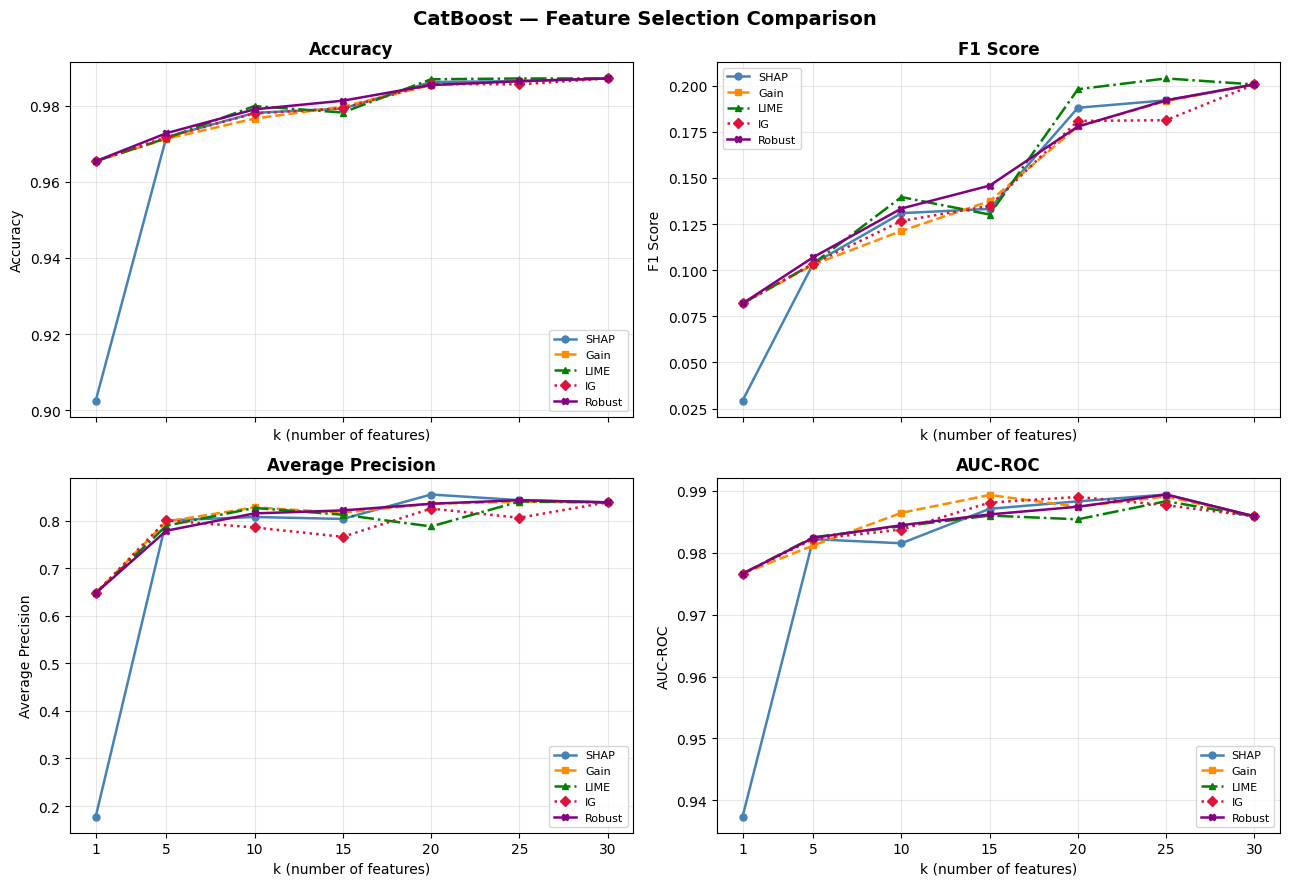

In [ ]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating CatBoost — SHAP...')
catboost_res_shap = evaluate_topk(MODELS['CatBoost'], catboost_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating CatBoost — Gain...')
catboost_res_gain = evaluate_topk(MODELS['CatBoost'], catboost_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if catboost_gain is not None else None

print('Evaluating CatBoost — LIME...')
catboost_res_lime = evaluate_topk(MODELS['CatBoost'], catboost_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating CatBoost — IG...')
catboost_res_ig = evaluate_topk(MODELS['CatBoost'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating CatBoost — Robust Bootstrap...')
catboost_res_robust = evaluate_topk(MODELS['CatBoost'], catboost_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'CatBoost',
    {'SHAP': catboost_res_shap, 'Gain': catboost_res_gain,
     'LIME': catboost_res_lime, 'IG':   catboost_res_ig, 'Robust': catboost_res_robust},
    k_values,
)


---
## GradientBoosting

### GradientBoosting — SHAP

In [ ]:
print('Computing SHAP ranking for GradientBoosting...')
gradientboosting_shap = get_shap_ranking(MODELS['GradientBoosting'], X_train_smote, y_train_smote)
print('Top-10:')
gradientboosting_shap.head(10)

Computing SHAP ranking for GradientBoosting...
Top-10:


,feature,importance
0,V14,16631.892505
1,V4,9999.920810
2,V12,4674.575552
3,V11,3164.212560
4,V10,2964.230854
5,V3,1872.807405
6,V1,1820.024780
7,V8,1650.845971
8,Time,1083.017882
9,V19,919.993046


### GradientBoosting — Gain

In [ ]:
print('Computing Gain ranking for GradientBoosting...')
gradientboosting_gain = get_gain_ranking(MODELS['GradientBoosting'], X_train_smote, y_train_smote)
if gradientboosting_gain is not None:
    print('Top-10:')
    display(gradientboosting_gain.head(10))
else:
    print('Gain not supported for GradientBoosting')


Computing Gain ranking for GradientBoosting...
Top-10:


,feature,importance
0,V14,0.758202
1,V4,0.066794
2,V12,0.024022
3,Amount,0.014897
4,V3,0.014458
5,V8,0.013374
6,V10,0.010758
7,V11,0.009376
8,V7,0.009206
9,V13,0.008377


### GradientBoosting — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [ ]:
print('Computing LIME ranking for GradientBoosting...')
gradientboosting_lime = get_lime_ranking(
    MODELS['GradientBoosting'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
gradientboosting_lime.head(10)

Computing LIME ranking for GradientBoosting...
Top-10:


,feature,importance
0,V4,0.261831
1,V14,0.237376
2,V12,0.118222
3,V10,0.099950
4,V3,0.076368
5,V11,0.053298
6,V1,0.036490
7,V8,0.032428
8,Amount,0.027249
9,V17,0.024441


### GradientBoosting — Robust

In [ ]:
gb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=gb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [29:13<00:00,  3.51s/it] 


In [ ]:
gb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=gb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [ ]:
tmp = gb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

gradientboosting_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
gradientboosting_robust.head(10)


,feature,importance
Rank,,
1,V14,15230.536558
2,V4,9382.084405
3,V12,6221.504907
4,V11,4016.036334
5,V10,3132.803086
6,V3,1998.915684
7,V1,1818.983408
8,V8,1736.288063
9,Time,1212.141211


### GradientBoosting — Evaluation & Comparison

Evaluating GradientBoosting — SHAP...
Evaluating GradientBoosting — Gain...
Evaluating GradientBoosting — LIME...
Evaluating GradientBoosting — IG...
Evaluating GradientBoosting — Robust Bootstrap...


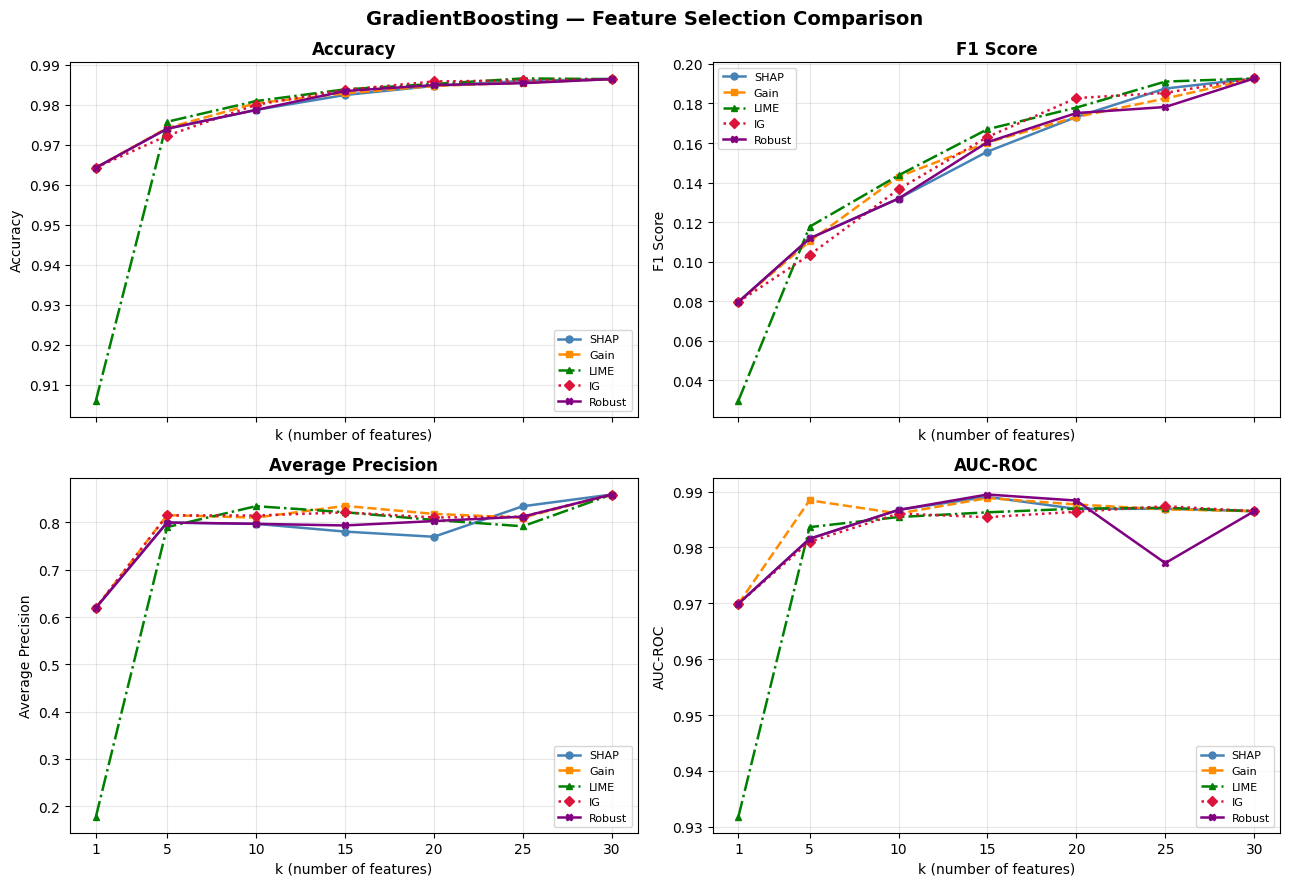

In [ ]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating GradientBoosting — SHAP...')
gradientboosting_res_shap = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating GradientBoosting — Gain...')
gradientboosting_res_gain = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if gradientboosting_gain is not None else None

print('Evaluating GradientBoosting — LIME...')
gradientboosting_res_lime = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating GradientBoosting — IG...')
gradientboosting_res_ig = evaluate_topk(MODELS['GradientBoosting'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating GradientBoosting — Robust Bootstrap...')
gradientboosting_res_robust = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'GradientBoosting',
    {'SHAP': gradientboosting_res_shap, 'Gain': gradientboosting_res_gain,
     'LIME': gradientboosting_res_lime, 'IG':   gradientboosting_res_ig, 'Robust': gradientboosting_res_robust},
    k_values,
)


---
## LogisticRegression

### LogisticRegression — SHAP

In [ ]:
print('Computing SHAP ranking for LogisticRegression...')
logisticregression_shap = get_shap_ranking(MODELS['LogisticRegression'], X_train_smote, y_train_smote)
print('Top-10:')
logisticregression_shap.head(10)

Computing SHAP ranking for LogisticRegression...
Top-10:


,feature,importance
0,V14,37672.961648
1,V12,29518.967151
2,V10,27759.625119
3,V17,22169.184254
4,V4,19560.913813
5,V8,9789.551209
6,V1,9338.358371
7,V16,9316.751305
8,V11,8367.359720
9,V7,6417.998609


### LogisticRegression — Gain

In [ ]:
print('Computing Gain ranking for LogisticRegression...')
logisticregression_gain = get_gain_ranking(MODELS['LogisticRegression'], X_train_smote, y_train_smote)
if logisticregression_gain is not None:
    print('Top-10:')
    display(logisticregression_gain.head(10))
else:
    print('Gain not supported for LogisticRegression')


Computing Gain ranking for LogisticRegression...
Top-10:


,feature,importance
0,V14,1.232470
1,V12,1.036763
2,V10,1.028581
3,V4,0.981589
4,V22,0.791856
5,V17,0.620792
6,V8,0.601522
7,V26,0.534536
8,V28,0.510320
9,V11,0.486973


### LogisticRegression — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [ ]:
print('Computing LIME ranking for LogisticRegression...')
logisticregression_lime = get_lime_ranking(
    MODELS['LogisticRegression'], X_train_smote, y_train_smote,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
logisticregression_lime.head(10)


Computing LIME ranking for LogisticRegression...
Top-10:


,feature,importance
0,V14,0.111813
1,V12,0.105603
2,V10,0.099746
3,V17,0.094480
4,V4,0.081500
5,V8,0.051087
6,V1,0.050030
7,V16,0.036693
8,V9,0.036028
9,V7,0.034840


### LogisticRegression — Robust

In [ ]:
lr_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train_smote,
    y=y_train_smote,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lr_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   0%|          | 2/500 [00:06<23:12,  2.80s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Bootstrap repeats (feature-agg):   1%|          | 3/500 [00:06<14:56,  1.80s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Bootstrap repeats (feature-agg):   1%|          | 4/500 [00:06<09:30,  1.15s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Bootstrap repeats (feature-agg):   1%|          | 5/500 [00:08<09:46,  1.18s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/skl

In [ ]:
lr_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lr_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [ ]:
tmp = lr_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

logisticregression_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
logisticregression_robust.head(10)


,feature,importance
Rank,,
1,V14,43820.972945
2,V12,32619.076462
3,V10,26666.001507
4,V4,21760.042497
5,V17,15082.599231
6,V8,11310.101060
7,V11,8741.662947
8,V7,6884.379888
9,V16,6330.527847


### LogisticRegression — Evaluation & Comparison

Evaluating LogisticRegression — SHAP...
Evaluating LogisticRegression — Gain...
Evaluating LogisticRegression — LIME...
Evaluating LogisticRegression — IG...
Evaluating LogisticRegression — Robust Bootstrap...


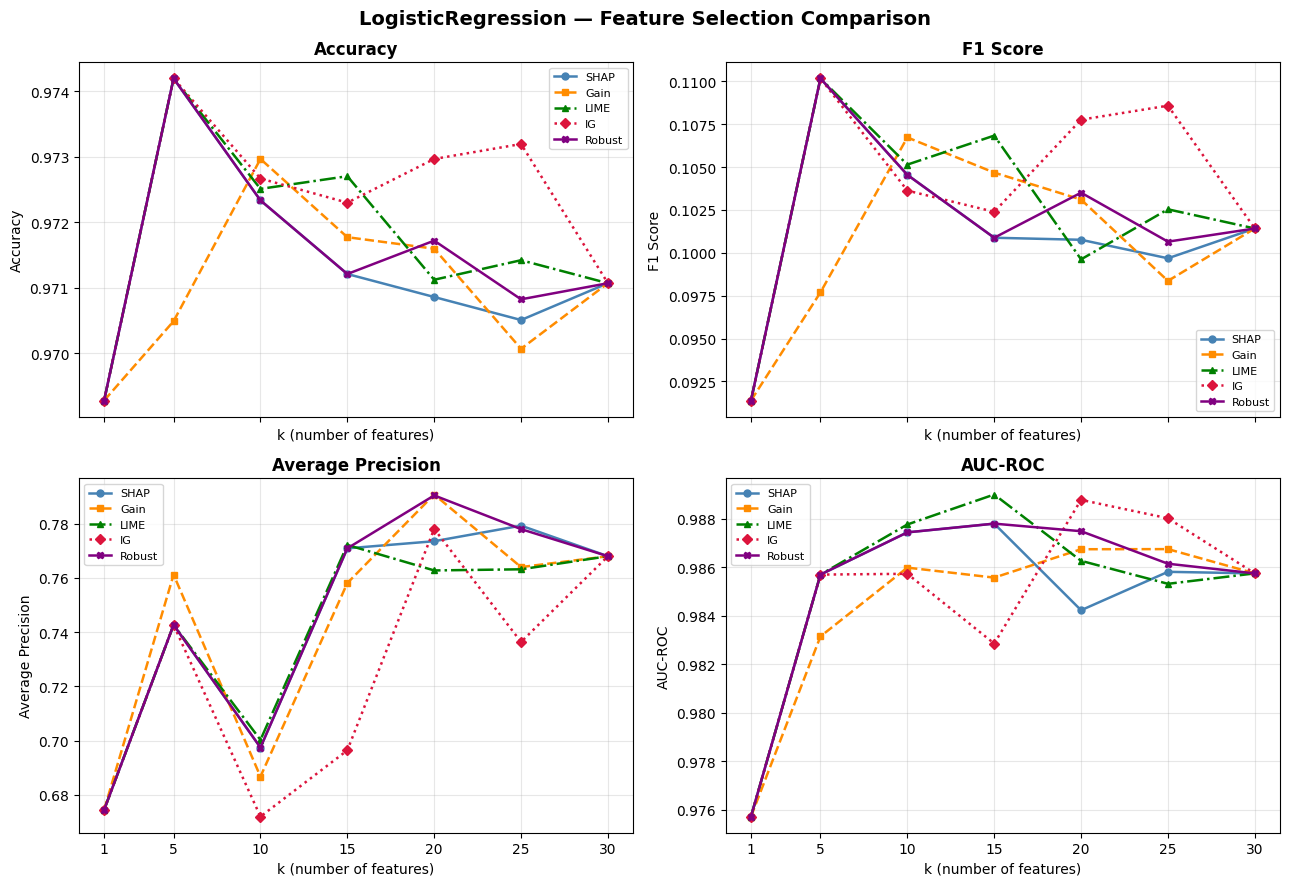

In [ ]:
k_values = [1, 5, 10, 15, 20, 25, max(30, len(X_train.columns))]

print('Evaluating LogisticRegression — SHAP...')
logisticregression_res_shap = evaluate_topk(MODELS['LogisticRegression'], logisticregression_shap, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LogisticRegression — Gain...')
logisticregression_res_gain = evaluate_topk(MODELS['LogisticRegression'], logisticregression_gain, X_train_smote, X_test, y_train_smote, y_test, k_values) if logisticregression_gain is not None else None

print('Evaluating LogisticRegression — LIME...')
logisticregression_res_lime = evaluate_topk(MODELS['LogisticRegression'], logisticregression_lime, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LogisticRegression — IG...')
logisticregression_res_ig = evaluate_topk(MODELS['LogisticRegression'], ig_ranking, X_train_smote, X_test, y_train_smote, y_test, k_values)

print('Evaluating LogisticRegression — Robust Bootstrap...')
logisticregression_res_robust = evaluate_topk(MODELS['LogisticRegression'], logisticregression_robust, X_train_smote, X_test, y_train_smote, y_test, k_values)

plot_comparison(
    'LogisticRegression',
    {'SHAP': logisticregression_res_shap, 'Gain': logisticregression_res_gain,
     'LIME': logisticregression_res_lime, 'IG':   logisticregression_res_ig, 'Robust': logisticregression_res_robust},
    k_values,
)
